# Работа с данными в Python и подготовка данных для LLM

## Цели занятия
- Научиться собирать и предобрабатывать данные для обучения языковых моделей на Python
- Освоить основные библиотеки (Pandas, NumPy) для обработки и трансформации данных
- Сформировать понимание специфики работы с русскоязычными данными
- Научиться формировать обучающие и тестовые выборки

## Краткое содержание
1. **Введение** - цели и краткое содержание
2. **Основные библиотеки** - Pandas и NumPy
3. **Работа с текстовыми данными** - парсинг, очистка, нормализация, токенизация
4. **Специфика русскоязычной обработки** - морфология, падежи, опечатки
5. **Формирование выборок и сериализация** - разделение данных, форматы JSON, CSV, Parquet
6. **Примеры использования API** - OpenAI и Hugging Face

**Длительность:** 90 минут

## Основные библиотеки для работы с данными

### Pandas - основа для работы с табличными данными
- Создание и манипуляция DataFrame
- Чтение/запись различных форматов данных
- Фильтрация, группировка, агрегация

### NumPy - математические операции и массивы
- Эффективная работа с числовыми данными
- Основа для других библиотек (Pandas, scikit-learn)
- Векторизованные операции

## 1. Установка зависимостей

Установим все необходимые библиотеки для работы с данными:

In [23]:
# Установка необходимых библиотек
%pip install pandas numpy beautifulsoup4 pymorphy3 transformers matplotlib seaborn
%pip install openai>=1.0.0  # для работы с OpenAI API
%pip install pyarrow  # для работы с Parquet файлами

In [24]:
# Импорт основных библиотек
import json
import os
import re
import time
import typing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymorphy3
import seaborn as sns
from bs4 import BeautifulSoup
from google.colab import userdata
from openai import OpenAI
from transformers import pipeline


# Настройка отображения
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
plt.style.use("default")
sns.set_palette("husl")

### 2. Практическое задание: Создание DataFrame

Давайте создадим простой DataFrame с отзывами для дальнейшей работы:

In [25]:
# Создаем примерную HTML страницу с отзывами
html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Отзывы о товарах</title>
</head>
<body>
    <div class="reviews">
        <div class="review">
            <h3>Обзор iPhone 14 Pro</h3>
            <p class="review-text">Потрясающий телефон с невероятным качеством камеры! Новые функции просто фантастические. Настоятельно рекомендую это устройство всем.</p>
            <span class="rating">5 звёзд</span>
        </div>

        <div class="review">
            <h3>Опыт с Tesla Model Y</h3>
            <p class="review-text">Большое спасибо за замечательное 5-часовое ожидание в сервисном центре! Абсолютно восхитительный опыт 👏. Хотя сама машина отличная.</p>
            <span class="rating">3 звезды</span>
        </div>

        <div class="review">
            <h3>Посещение ресторана</h3>
            <p class="review-text">Еда была приличной, а атмосфера приятной, но обслуживание оставляло желать лучшего. Смешанные чувства по поводу этого места.</p>
            <span class="rating">3 звезды</span>
        </div>

        <div class="review">
            <h3>Покупка ноутбука</h3>
            <p class="review-text">Ужасный опыт в магазине электроники на Главной улице. Продавец Джон Смит был совершенно бесполезен и груб.</p>
            <span class="rating">1 звезда</span>
        </div>

        <div class="review">
            <h3>Банковское обслуживание</h3>
            <p class="review-text">Хотя комиссии банка высоки, а время ожидания может быть долгим, я в целом доволен качеством их обслуживания клиентов.</p>
            <span class="rating">4 звезды</span>
        </div>

        <div class="review">
            <h3>Онлайн-покупки</h3>
            <p class="review-text">Отличный Samsung Galaxy S24 Ultra, купленный в Best Buy! Консультант Дэвид Джонсон всё прекрасно объяснил. Обожаю новые функции камеры.</p>
            <span class="rating">5 звёзд</span>
        </div>

        <div class="review">
            <h3>Проживание в отеле</h3>
            <p class="review-text">Не могу сказать, что отель Хилтон был плохим, просто ожидал большего за цену, которую мы заплатили. Обслуживание было нормальным, номер чистым.</p>
            <span class="rating">3 звезды</span>
        </div>

        <div class="review">
            <h3>Служба доставки</h3>
            <p class="review-text">Заказал доставку еды из ресторана "Итальянский сад" - привезли холодную, но водитель Майк был очень вежлив и извинялся.</p>
            <span class="rating">2 звезды</span>
        </div>
    </div>
</body>
</html>
"""

# Сохраняем HTML в файл
with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_content)
    print("HTML файл с отзывами создан!")

HTML файл с отзывами создан!


In [26]:
# Сначала загрузим и обработаем данные из index.html
def parse_reviews_from_html(html_file_path: str) -> list[dict[str, str]]:
    """Парсинг отзывов из HTML файла с помощью BeautifulSoup."""
    with open(html_file_path, encoding="utf-8") as file:
        content = file.read()

    soup = Beautifu0lSoup(content, "html.parser")
    reviews = []

    # Находим все блоки с отзывами
    review_blocks = soup.find_all("div", class_="review")

    for one_block in review_blocks:
        # Извлекаем заголовок
        title_elem = one_block.find("h3")
        title = title_elem.get_text().strip() if title_elem else ""

        # Извлекаем текст отзыва
        text_elem = one_block.find("p", class_="review-text")
        text = text_elem.get_text().strip() if text_elem else ""

        # Извлекаем рейтинг
        rating_elem = one_block.find("span", class_="rating")
        rating = rating_elem.get_text().strip() if rating_elem else ""

        if text:  # Добавляем только если есть текст
            reviews.append({
                "title": title,
                "text": text,
                "rating": rating
            })

    return reviews

In [27]:
# Парсим отзывы из HTML файла
html_reviews = parse_reviews_from_html("index.html")

# Создаем DataFrame из распарсенных данных
df = pd.DataFrame(html_reviews)

print(f"Загружено {df.shape[0]} отзывов из HTML файла:")
df.head()

Загружено 8 отзывов из HTML файла:


,title,text,rating
0,Обзор iPhone 14 Pro,Потрясающий телефон с невероятным качеством ка...,5 звёзд
1,Опыт с Tesla Model Y,Большое спасибо за замечательное 5-часовое ожи...,3 звезды
2,Посещение ресторана,"Еда была приличной, а атмосфера приятной, но о...",3 звезды
3,Покупка ноутбука,Ужасный опыт в магазине электроники на Главной...,1 звезда
4,Банковское обслуживание,"Хотя комиссии банка высоки, а время ожидания м...",4 звезды


## 3. Работа с текстовыми данными

### Парсинг данных

Часто данные приходят в различных форматах: HTML, JSON, CSV. Рассмотрим парсинг HTML-страницы с отзывами:

In [28]:
# Анализ структуры данных
print("Структура данных:")
print(f"Количество отзывов: {df.shape[0]}")
print(f"Колонки: {list(df.columns)}")

print("\nПримеры рейтингов:")
print(df["rating"].value_counts())

print("\nПримеры заголовков:")
for one_index, one_title in enumerate(df["title"].head(3)):
    print(f"{one_index+1}. {one_title}")

print("\nДлина текстов отзывов:")
df["text_length"] = df["text"].str.len()
print(f"Средняя длина: {df['text_length'].mean():.1f} символов")
print(f"Минимальная: {df['text_length'].min()} символов")
print(f"Максимальная: {df['text_length'].max()} символов")

Структура данных:
Количество отзывов: 8
Колонки: ['title', 'text', 'rating']

Примеры рейтингов:
rating
3 звезды    3
5 звёзд     2
1 звезда    1
4 звезды    1
2 звезды    1
Name: count, dtype: int64

Примеры заголовков:
1. Обзор iPhone 14 Pro
2. Опыт с Tesla Model Y
3. Посещение ресторана

Длина текстов отзывов:
Средняя длина: 126.0 символов
Минимальная: 106 символов
Максимальная: 143 символов


### Очистка и нормализация текста

Реальные данные часто содержат:
- Лишние пробелы
- Специальные символы
- Неправильный регистр
- Повторяющиеся знаки препинания

In [29]:
def clean_text(text: str) -> str:
    """Базовая очистка русскоязычного текста."""
    if not text or pd.isna(text):
        return ""

    # Удаляем эмодзи и специальные символы (оставляем буквы, цифры, пробелы и базовую пунктуацию)
    text = re.sub(r"[^\w\s\-.,!?;:()]", "", text)

    # Нормализуем пробелы
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    # Убираем повторяющиеся знаки препинания
    text = re.sub(r"[.]{2,}", ".", text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)

    # Приводим к правильному регистру (первая буква заглавная)
    if text:
        text = text[0].upper() + text[1:].lower()

    return text

# Тестирование функции на реальных данных
print("Тестирование функции очистки:")
print("До очистки:")
for one_index, one_text in enumerate(df["text"].head(3)):
    print(f"{one_index+1}. {one_text}")

# Применяем очистку к колонке с текстами
df["cleaned_text"] = df["text"].apply(clean_text)

print("\nПосле очистки:")
for one_index, one_text in enumerate(df["cleaned_text"].head(3)):
    print(f"{one_index+1}. {one_text}")

# Сравним длины текстов до и после очистки
print(f"\nСредняя длина до очистки: {df['text'].str.len().mean():.1f}")
print(f"Средняя длина после очистки: {df['cleaned_text'].str.len().mean():.1f}")

Тестирование функции очистки:
До очистки:
1. Потрясающий телефон с невероятным качеством камеры! Новые функции просто фантастические. Настоятельно рекомендую это устройство всем.
2. Большое спасибо за замечательное 5-часовое ожидание в сервисном центре! Абсолютно восхитительный опыт 👏. Хотя сама машина отличная.
3. Еда была приличной, а атмосфера приятной, но обслуживание оставляло желать лучшего. Смешанные чувства по поводу этого места.

После очистки:
1. Потрясающий телефон с невероятным качеством камеры! новые функции просто фантастические. настоятельно рекомендую это устройство всем.
2. Большое спасибо за замечательное 5-часовое ожидание в сервисном центре! абсолютно восхитительный опыт . хотя сама машина отличная.
3. Еда была приличной, а атмосфера приятной, но обслуживание оставляло желать лучшего. смешанные чувства по поводу этого места.

Средняя длина до очистки: 126.0
Средняя длина после очистки: 125.6


### Токенизация

Разбиение текста на отдельные слова (токены) - важный этап предобработки:

In [30]:
def simple_tokenize(text: str) -> list[str]:
    """Простая токенизация текста."""
    if not text or pd.isna(text):
        return []

    # Приводим к нижнему регистру и извлекаем только слова
    return re.findall(r"\b\w+\b", text.lower())
    # Альтернативный вариант без regexp
    # tokens = [one_word.lower() for one_word in text.split()]

def advanced_tokenize(text: str) -> dict[str, typing.Any]:
    """Расширенная токенизация с дополнительной информацией."""
    if not text or pd.isna(text):
        return {"tokens": [], "word_count": 0, "unique_words": 0}

    tokens = simple_tokenize(text)

    return {
        "tokens": tokens,
        "word_count": len(tokens),
        "unique_words": len(set(tokens)),
        "avg_word_length": np.mean([len(one_token) for one_token in tokens]) if tokens else 0
    }

# Применяем токенизацию к нашим данным
print("Тестирование токенизации:")

sample_texts = df["cleaned_text"].head(3).tolist()
for one_index, one_text in enumerate(sample_texts):
    print(f"\nТекст {one_index+1}: {one_text}")

    # Простая токенизация
    tokens = simple_tokenize(one_text)
    print(f"Токены: {tokens[:10]}...")  # первые 10 токенов

    # Расширенная токенизация
    token_info = advanced_tokenize(one_text)
    print(
        f"Статистика: {token_info['word_count']} слов, "
        f"{token_info['unique_words']} уникальных, "
        f"средняя длина слова: {token_info['avg_word_length']:.1f}"
        )

# Применяем токенизацию ко всему датасету
df["tokens"] = df["cleaned_text"].apply(simple_tokenize)
df["word_count"] = df["tokens"].apply(len)
df["unique_word_count"] = df["tokens"].apply(lambda x: len(set(x)))

print("\nСтатистика по всему датасету:")
print(f"Среднее количество слов в отзыве: {df['word_count'].mean():.1f}")
print(f"Среднее количество уникальных слов: {df['unique_word_count'].mean():.1f}")
print(f"Самый длинный отзыв: {df['word_count'].max()} слов")
print(f"Самый короткий отзыв: {df['word_count'].min()} слов")

Тестирование токенизации:

Текст 1: Потрясающий телефон с невероятным качеством камеры! новые функции просто фантастические. настоятельно рекомендую это устройство всем.
Токены: ['потрясающий', 'телефон', 'с', 'невероятным', 'качеством', 'камеры', 'новые', 'функции', 'просто', 'фантастические']...
Статистика: 15 слов, 15 уникальных, средняя длина слова: 7.7

Текст 2: Большое спасибо за замечательное 5-часовое ожидание в сервисном центре! абсолютно восхитительный опыт . хотя сама машина отличная.
Токены: ['большое', 'спасибо', 'за', 'замечательное', '5', 'часовое', 'ожидание', 'в', 'сервисном', 'центре']...
Статистика: 17 слов, 17 уникальных, средняя длина слова: 6.5

Текст 3: Еда была приличной, а атмосфера приятной, но обслуживание оставляло желать лучшего. смешанные чувства по поводу этого места.
Токены: ['еда', 'была', 'приличной', 'а', 'атмосфера', 'приятной', 'но', 'обслуживание', 'оставляло', 'желать']...
Статистика: 17 слов, 17 уникальных, средняя длина слова: 6.1

Статистика по

## 4. Специфика русскоязычной обработки данных

### Морфология и падежи

Русский язык имеет сложную морфологию:
- 6 падежей
- Множественные формы слов
- Различные окончания

Для работы с русской морфологией часто используется библиотека **pymorphy2**.

In [31]:
# Инициализируем морфологический анализатор
morph = pymorphy3.MorphAnalyzer()

def analyze_morphology(text: str) -> dict[str, typing.Any]:
    """Морфологический анализ русского текста."""
    if not text:
        return {"lemmas": [], "pos_tags": [], "morphology": []}

    tokens = simple_tokenize(text)
    # lemmas - список с нормальными формами слов
    lemmas = []
    # pos_tags - список с частями речи
    pos_tags = []
    # morphology_info - список словарей с расширенной информацией о каждом токене
    # word: исходное слово
    # lemma: нормальная форма слова
    # pos: часть речи (как в pos_tags)
    # case: падеж (если применимо) — именительный (nomn), родительный (gent), дательный (datv),
    #                                винительный (accs), творительный (ablt), предложный (loct)
    #                                и звательный (voct - устаревший и использутеся для исторических текстов)
    # number: число — единственное (sing) или множественное (plur)
    morphology_info = []

    for one_token in tokens:
        parsed = morph.parse(one_token)[0]  # берем первый (наиболее вероятный) разбор
        lemmas.append(parsed.normal_form)
        pos_tags.append(parsed.tag.POS)
        morphology_info.append({
            "word": one_token,
            "lemma": parsed.normal_form,
            "pos": parsed.tag.POS,
            "case": getattr(parsed.tag, "case", None),
            "number": getattr(parsed.tag, "number", None)
        })

    return {
        "lemmas": lemmas,
        "pos_tags": pos_tags,
        "morphology": morphology_info
    }

# Демонстрация морфологического анализа
print("Демонстрация морфологического анализа:")

sample_text = "Потрясающий телефон с невероятным качеством камеры!"
print(f"Исходный текст: {sample_text}")

morph_result = analyze_morphology(sample_text)
print(f"Леммы: {morph_result['lemmas']}")
print(f"Части речи: {morph_result['pos_tags']}")

print("\nДетальный разбор:")
for one_item in morph_result["morphology"]:
    print(f"  {one_item['word']} -> {one_item['lemma']} ({one_item['pos']})")

# Применяем морфологический анализ к нескольким примерам
print("\n" + "="*50)
print("Анализ первых трех отзывов:")

for one_index, one_text in enumerate(df["cleaned_text"].head(3)):
    print(f"\nОтзыв {one_index+1}: {one_text}")
    result = analyze_morphology(one_text)
    print(f"Основные формы слов: {result['lemmas'][:8]}...")  # первые 8 лемм

    # Считаем частоту частей речи
    pos_counts = {}
    for one_pos in result["pos_tags"]:
        if one_pos:
            pos_counts[one_pos] = pos_counts.get(one_pos, 0) + 1
    print(f"Части речи: {pos_counts}")

# Добавляем леммы в датасет
print("\nДобавляем леммы в датасет...")
df["lemmas"] = df["cleaned_text"].apply(lambda x: analyze_morphology(x)["lemmas"])
df["lemmas_count"] = df["lemmas"].apply(len)

print(f"Среднее количество лемм в отзыве: {df['lemmas_count'].mean():.1f}")

Демонстрация морфологического анализа:
Исходный текст: Потрясающий телефон с невероятным качеством камеры!
Леммы: ['потрясать', 'телефон', 'с', 'невероятный', 'качество', 'камера']
Части речи: ['PRTF', 'NOUN', 'PREP', 'ADJF', 'NOUN', 'NOUN']

Детальный разбор:
  потрясающий -> потрясать (PRTF)
  телефон -> телефон (NOUN)
  с -> с (PREP)
  невероятным -> невероятный (ADJF)
  качеством -> качество (NOUN)
  камеры -> камера (NOUN)

Анализ первых трех отзывов:

Отзыв 1: Потрясающий телефон с невероятным качеством камеры! новые функции просто фантастические. настоятельно рекомендую это устройство всем.
Основные формы слов: ['потрясать', 'телефон', 'с', 'невероятный', 'качество', 'камера', 'новый', 'функция']...
Части речи: {'PRTF': 1, 'NOUN': 5, 'PREP': 1, 'ADJF': 4, 'PRCL': 2, 'ADVB': 1, 'VERB': 1}

Отзыв 2: Большое спасибо за замечательное 5-часовое ожидание в сервисном центре! абсолютно восхитительный опыт . хотя сама машина отличная.
Основные формы слов: ['большой', 'спасибо', 'за', 'за

### Обработка опечаток

В реальных данных часто встречаются опечатки. Рассмотрим простые подходы к их исправлению:

In [32]:
# Простая система исправления опечаток на основе словаря
def create_typo_correction_dict() -> dict[str, str]:
    """Создаем словарь для исправления типичных опечаток."""
    return {
        # Часто встречающиеся опечатки в отзывах о технике
        "телифон": "телефон",
        "тилефон": "телефон",
        "телефгон": "телефон",
        "айфон": "iphone",
        "айфонн": "iphone",
        "отличьный": "отличный",
        "отлишный": "отличный",
        "атличный": "отличный",
        "покупа": "покупка",
        "покупк": "покупка",
        "покупака": "покупка",
        "магазин": "магазин",
        "магзин": "магазин",
        "магозин": "магазин",
        "камерра": "камера",
        "каммера": "камера",
        "качестов": "качество",
        "качествво": "качество",
        "обслуживанее": "обслуживание",
        "обслуживоние": "обслуживание",
        "менеджерр": "менеджер",
        "сотрудник": "сотрудник",
        "сотруднки": "сотрудники",
        "вобще": "вообще",
        "вооще": "вообще",
        "востхитительно": "восхитительно",
        "восхитетельно": "восхитительно"
    }

def correct_typos(text: str, correction_dict: dict[str, str]) -> str:
    """Исправление опечаток в тексте на основе словаря."""
    if not text:
        return text

    words = text.split()
    corrected_words = []

    for one_word in words:
        # Убираем знаки препинания для проверки
        clean_word = re.sub(r"[^\w]", "", one_word.lower())

        if clean_word in correction_dict:
            # Заменяем чистое слово на правильное, сохраняя пунктуацию
            corrected_word = re.sub(re.escape(clean_word), correction_dict[clean_word], one_word, flags=re.IGNORECASE)
            corrected_words.append(corrected_word)
        else:
            corrected_words.append(one_word)

    return " ".join(corrected_words)

In [33]:
# Тестирование системы исправления опечаток
typo_dict = create_typo_correction_dict()

print("Демонстрация исправления опечаток:")
test_texts_with_typos = [
    "Отличьный телифон! Очень доволен покупа.",
    "Ужасное обслуживанее в магозин на красной площади.",
    "Айфон 13 хороший телефгон, камерра супер!"
]

for one_index, one_text in enumerate(test_texts_with_typos):
    corrected = correct_typos(one_text, typo_dict)
    print(f"\nПример {one_index+1}:")
    print(f"  До: {one_text}")
    print(f"  После: {corrected}")

# Применяем исправление опечаток к нашим данным (опционально, только для демонстрации)
print("\n" + "="*50)
print("Проверяем, есть ли опечатки в наших данных:")

# Ищем потенциальные опечатки в датасете
found_typos = []
for one_index, one_text in enumerate(df["cleaned_text"]):
    for one_typo, one_correction in typo_dict.items():
        if one_typo in one_text.lower():
            found_typos.append({
                "index": one_index,
                "text": one_text,
                "typo": one_typo,
                "correction": one_correction
            })

if found_typos:
    print(f"Найдено {len(found_typos)} потенциальных опечаток:")
    for one_typo_info in found_typos[:3]:  # показываем первые 3
        print(
            f"  Индекс {one_typo_info['index']}: '{one_typo_info['typo']}' "
            f"-> '{one_typo_info['correction']}'"
            )
else:
    print("В нашем датасете опечаток из словаря не найдено.")

# Создаем исправленную версию текстов
df["text_corrected"] = df["cleaned_text"].apply(lambda x: correct_typos(x, typo_dict))

print("Создана колонка 'text_corrected' с исправленными опечатками.")

Демонстрация исправления опечаток:

Пример 1:
  До: Отличьный телифон! Очень доволен покупа.
  После: отличный телефон! Очень доволен покупка.

Пример 2:
  До: Ужасное обслуживанее в магозин на красной площади.
  После: Ужасное обслуживание в магазин на красной площади.

Пример 3:
  До: Айфон 13 хороший телефгон, камерра супер!
  После: iphone 13 хороший телефон, камера супер!

Проверяем, есть ли опечатки в наших данных:
Найдено 1 потенциальных опечаток:
  Индекс 3: 'магазин' -> 'магазин'
Создана колонка 'text_corrected' с исправленными опечатками.


### Практическое задание: Обработка русского текста

Создадим функцию для комплексной обработки русскоязычного текста:

In [34]:
def process_russian_text(text: str) -> dict[str, typing.Any]:
    """Комплексная обработка русскоязычного текста."""
    if not text or pd.isna(text):
        return {
            "original": text,
            "cleaned": "",
            "corrected": "",
            "tokens": [],
            "lemmas": [],
            "word_count": 0,
            "char_count": 0,
            "unique_word_count": 0,
            "avg_word_length": 0
        }

    # 1. Очистка текста
    cleaned = clean_text(text)

    # 2. Исправление опечаток
    corrected = correct_typos(cleaned, create_typo_correction_dict())

    # 3. Токенизация
    tokens = simple_tokenize(corrected)

    # 4. Морфологический анализ
    morphology_result = analyze_morphology(corrected)
    lemmas = morphology_result["lemmas"]

    # 5. Статистики
    word_count = len(tokens)
    char_count = len(corrected)
    unique_word_count = len(set(tokens))
    avg_word_length = np.mean([len(one_token) for one_token in tokens]) if tokens else 0

    return {
        "original": text,
        "cleaned": cleaned,
        "corrected": corrected,
        "tokens": tokens,
        "lemmas": lemmas,
        "word_count": word_count,
        "char_count": char_count,
        "unique_word_count": unique_word_count,
        "avg_word_length": avg_word_length
    }

In [35]:
# Тестирование комплексной обработки
print("Комплексная обработка русскоязычного текста:")

test_text = "Потрясающий телифон с невероятным качеством камерры!!! Очень доволен покупа в магозин Apple."
print(f"Исходный текст: {test_text}")

processed = process_russian_text(test_text)

print(f"Очищенный: {processed['cleaned']}")
print(f"Исправленный: {processed['corrected']}")
print(f"Токены: {processed['tokens']}")
print(f"Леммы: {processed['lemmas']}")
print("Статистики:")
print(f"  - Слов: {processed['word_count']}")
print(f"  - Символов: {processed['char_count']}")
print(f"  - Уникальных слов: {processed['unique_word_count']}")
print(f"  - Средняя длина слова: {processed['avg_word_length']:.1f}")

# Применяем комплексную обработку к выбранным отзывам
print("\n" + "="*50)
print("Обработка отзывов из датасета:")

for one_index, one_text in enumerate(df["text"].head(2)):  # берем первые 2 отзыва
    print(f"\nОтзыв {one_index+1}:")
    result = process_russian_text(one_text)
    print(f"  Исходный: {result['original']}")
    print(f"  Обработанный: {result['corrected']}")
    print(f"  Леммы: {result['lemmas'][:6]}...")  # первые 6 лемм
    print(f"  Статистики: {result['word_count']} слов, {result['unique_word_count']} уникальных")

# Создаем новый DataFrame с результатами комплексной обработки
print("\nСоздаем расширенный датасет с результатами обработки...")

processed_data = []
for one_index, one_text in enumerate(df["text"]):
    result = process_russian_text(one_text)
    processed_item = {
        "id": one_index,
        "original_text": one_text,
        "title": df.iloc[one_index]["title"],
        "rating": df.iloc[one_index]["rating"],
        "processed_text": result["corrected"],
        "tokens": result["tokens"],
        "lemmas": result["lemmas"],
        "word_count": result["word_count"],
        "char_count": result["char_count"],
        "unique_word_count": result["unique_word_count"],
        "avg_word_length": result["avg_word_length"]
    }
    processed_data.append(processed_item)

# Создаем новый DataFrame
processed_df = pd.DataFrame(processed_data)

print(
    f"Создан обработанный датасет с {processed_df.shape[0]} записями и "
    f"{len(processed_df.columns)} колонками:"
    )
print(processed_df.columns.to_list())

Комплексная обработка русскоязычного текста:
Исходный текст: Потрясающий телифон с невероятным качеством камерры!!! Очень доволен покупа в магозин Apple.
Очищенный: Потрясающий телифон с невероятным качеством камерры! очень доволен покупа в магозин apple.
Исправленный: Потрясающий телефон с невероятным качеством камерры! очень доволен покупка в магазин apple.
Токены: ['потрясающий', 'телефон', 'с', 'невероятным', 'качеством', 'камерры', 'очень', 'доволен', 'покупка', 'в', 'магазин', 'apple']
Леммы: ['потрясать', 'телефон', 'с', 'невероятный', 'качество', 'камерра', 'очень', 'довольный', 'покупка', 'в', 'магазин', 'apple']
Статистики:
  - Слов: 12
  - Символов: 91
  - Уникальных слов: 12
  - Средняя длина слова: 6.5

Обработка отзывов из датасета:

Отзыв 1:
  Исходный: Потрясающий телефон с невероятным качеством камеры! Новые функции просто фантастические. Настоятельно рекомендую это устройство всем.
  Обработанный: Потрясающий телефон с невероятным качеством камеры! новые функции прост

## 5. Формирование обучающих и тестовых выборок

### Принципы разделения данных

При подготовке данных для машинного обучения важно правильно разделить данные:
- **Обучающая выборка (train)** - 70-80%
- **Валидационная выборка (validation)** - 10-15%
- **Тестовая выборка (test)** - 10-15%

In [36]:
def split_data(
        df: pd.DataFrame,
        train_ratio: float=0.7,
        val_ratio: float=0.15
) -> dict[str, pd.DataFrame]:
    """Разделение данных на обучающую, валидационную и тестовую выборки."""
    n = df.shape[0]

    # Перемешиваем индексы для случайного разделения
    shuffled_indices = np.random.permutation(n)

    # Вычисляем размеры выборок
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    # Разделяем индексы
    train_indices = shuffled_indices[:train_size]
    val_indices = shuffled_indices[train_size:train_size + val_size]
    test_indices = shuffled_indices[train_size + val_size:]

    return {
        "train": df.iloc[train_indices].reset_index(drop=True),
        "validation": df.iloc[val_indices].reset_index(drop=True),
        "test": df.iloc[test_indices].reset_index(drop=True)
    }

def analyze_data_split(splits: dict[str, pd.DataFrame]) -> None:
    """Анализ разделенных данных."""
    print("Анализ разделения данных:")
    total_samples = sum(one_split_df.shape[0] for one_split_df in splits.values())

    for one_split_name, one_split_df in splits.items():
        size = one_split_df.shape[0]
        percentage = (size / total_samples) * 100
        avg_word_count = one_split_df["word_count"].mean() if "word_count" in one_split_df.columns else 0

        print(
            f"{one_split_name.capitalize():12}: {size:3} образцов ({percentage:5.1f}%), "
            f"среднее количество слов: {avg_word_count:.1f}"
            )

In [37]:
# Установим random seed для воспроизводимости
np.random.seed(42)

# Разделяем наш обработанный датасет
print("Разделение данных на train/validation/test:")
data_splits = split_data(processed_df, train_ratio=0.7, val_ratio=0.15)

# Анализируем разделение
analyze_data_split(data_splits)

# Показываем примеры из каждой выборки
print("\\nПримеры из каждой выборки:")
for one_split_name, one_split_df in data_splits.items():
    if not one_split_df.empty:
        sample_idx = 0
        sample = one_split_df.iloc[sample_idx]
        print(f"\\n{one_split_name.capitalize()}:")
        print(f"  Заголовок: {sample['title']}")
        print(f"  Рейтинг: {sample['rating']}")
        print(f"  Текст: {sample['processed_text'][:50]}...")
        print(
            f"  Статистики: {sample['word_count']} слов,"
            f" {sample['unique_word_count']} уникальных"
        )

# Создаем сводную статистику по разделению
print("\\n" + "="*50)
print("Сводная статистика по выборкам:")

stats_df = pd.DataFrame(
    {
        "Split": list(data_splits.keys()),
        "Size": [one_df.shape[0] for one_df in data_splits.values()],
        "Avg_Words": [one_df["word_count"].mean() for one_df in data_splits.values()],
        "Avg_Chars": [one_df["char_count"].mean() for one_df in data_splits.values()],
        "Avg_Unique_Words": [one_df["unique_word_count"].mean() for one_df in data_splits.values()]
    }
)

print(stats_df.round(1))

Разделение данных на train/validation/test:
Анализ разделения данных:
Train       :   5 образцов ( 62.5%), среднее количество слов: 17.0
Validation  :   1 образцов ( 12.5%), среднее количество слов: 18.0
Test        :   2 образцов ( 25.0%), среднее количество слов: 18.5
\nПримеры из каждой выборки:
\nTrain:
  Заголовок: Опыт с Tesla Model Y
  Рейтинг: 3 звезды
  Текст: Большое спасибо за замечательное 5-часовое ожидани...
  Статистики: 17 слов, 17 уникальных
\nValidation:
  Заголовок: Банковское обслуживание
  Рейтинг: 4 звезды
  Текст: Хотя комиссии банка высоки, а время ожидания может...
  Статистики: 18 слов, 18 уникальных
\nTest:
  Заголовок: Покупка ноутбука
  Рейтинг: 1 звезда
  Текст: Ужасный опыт в магазине электроники на главной ули...
  Статистики: 16 слов, 16 уникальных
\n==================================================
Сводная статистика по выборкам:
        Split  Size  Avg_Words  Avg_Chars  Avg_Unique_Words
0       train     5       17.0      127.8              17.0
1  

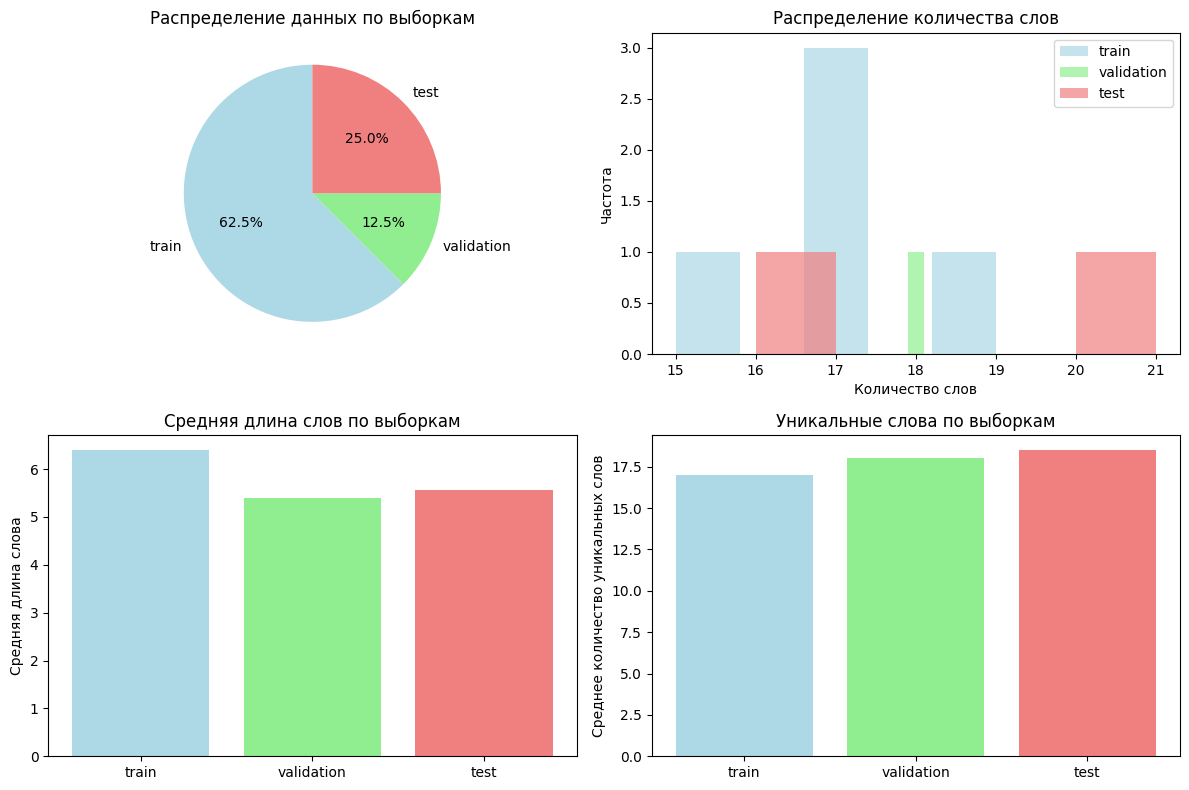

\nДанные успешно разделены на 3 выборки.


In [38]:
# Визуализация разделения данных
plt.figure(figsize=(12, 8))

# График 1: Размеры выборок
plt.subplot(2, 2, 1)
sizes = [one_df.shape[0] for one_df in data_splits.values()]
labels = list(data_splits.keys())
colors = ["lightblue", "lightgreen", "lightcoral"]
plt.pie(sizes, labels=labels, colors=colors,autopct="%1.1f%%", startangle=90)
plt.title("Распределение данных по выборкам")

# График 2: Распределение количества слов
plt.subplot(2, 2, 2)
for one_index, (one_split_name, one_split_df) in enumerate(data_splits.items()):
    plt.hist(one_split_df["word_count"], alpha=0.7, label=one_split_name, color=colors[one_index], bins=5)
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.title("Распределение количества слов")
plt.legend()

# График 3: Средняя длина слов
plt.subplot(2, 2, 3)
avg_word_lengths = [df["avg_word_length"].mean() for df in data_splits.values()]
plt.bar(labels, avg_word_lengths, color=colors)
plt.ylabel("Средняя длина слова")
plt.title("Средняя длина слов по выборкам")

# График 4: Количество уникальных слов
plt.subplot(2, 2, 4)
unique_words = [df["unique_word_count"].mean() for df in data_splits.values()]
plt.bar(labels, unique_words, color=colors)
plt.ylabel("Среднее количество уникальных слов")
plt.title("Уникальные слова по выборкам")

plt.tight_layout()
plt.show()

print(f"\\nДанные успешно разделены на {len(data_splits)} выборки.")

### Сериализация данных

Рассмотрим основные форматы для сохранения данных:

#### JSON - для структурированных данных
- Читаемость
- Поддержка веб-приложений
- Гибкость структуры

#### CSV - для табличных данных
- Простота
- Совместимость с Excel
- Малый размер

#### Parquet - для больших объемов данных
- Сжатие
- Быстрое чтение
- Сохранение типов данных

In [39]:
def save_data_multiple_formats(df: pd.DataFrame, base_filename: str) -> dict[str, str]:
    """Сохранение данных в различных форматах с анализом размеров файлов."""
    saved_files = {}

    # Подготавливаем данные для сохранения (убираем списки для CSV)
    df_for_save = df.copy()

    # Преобразуем списки в строки для CSV совместимости
    if "tokens" in df_for_save.columns:
        df_for_save["tokens_str"] = df_for_save["tokens"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
    if "lemmas" in df_for_save.columns:
        df_for_save["lemmas_str"] = df_for_save["lemmas"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

    # Удаляем оригинальные колонки со списками для CSV
    csv_df = df_for_save.drop(columns=["tokens", "lemmas"], errors="ignore")

    try:
        # JSON - сохраняем со списками
        json_file = f"{base_filename}.json"
        df.to_json(json_file, orient="records", force_ascii=False, indent=2)
        saved_files["json"] = json_file
        print(f"✓ JSON: {json_file}")

        # CSV - сохраняем без списков
        csv_file = f"{base_filename}.csv"
        csv_df.to_csv(csv_file, index=False, encoding="utf-8")
        saved_files["csv"] = csv_file
        print(f"✓ CSV: {csv_file}")

        # Parquet - сохраняем без списков (Parquet не поддерживает вложенные структуры)
        try:
            parquet_file = f"{base_filename}.parquet"
            csv_df.to_parquet(parquet_file, index=False)
            saved_files["parquet"] = parquet_file
            print(f"✓ Parquet: {parquet_file}")
        except Exception as e:
            print(f"⚠ Parquet: Ошибка сохранения - {str(e)}")
            print("  Возможно, нужно установить pyarrow: pip install pyarrow")

    except Exception as e:
        print(f"Ошибка при сохранении: {e}")

    return saved_files

def compare_file_sizes(saved_files: dict[str, str]) -> pd.DataFrame:
    """Сравнение размеров файлов в разных форматах."""
    file_stats = []

    for one_fmt, one_filepath in saved_files.items():
        if os.path.exists(one_filepath):
            size_bytes = os.path.getsize(one_filepath)
            size_kb = size_bytes / 1024

            file_stats.append({
                "Format": one_fmt.upper(),
                "File": os.path.basename(one_filepath),
                "Size_Bytes": size_bytes,
                "Size_KB": round(size_kb, 2),
                "Relative_Size": 1.0  # будет пересчитано
            })

    if file_stats:
        stats_df = pd.DataFrame(file_stats)

        # Вычисляем относительные размеры (относительно самого маленького файла)
        min_size = stats_df["Size_Bytes"].min()
        stats_df["Relative_Size"] = (stats_df["Size_Bytes"] / min_size).round(2)

        return stats_df
    return pd.DataFrame()

In [40]:
# Сохраняем данные в различных форматах
print("Сохранение данных в различных форматах:")
print("="*50)

# Сохраняем обучающую выборку
train_files = save_data_multiple_formats(data_splits["train"], "train_data")

print("\\nСохраняем валидационную выборку:")
val_files = save_data_multiple_formats(data_splits["validation"], "val_data")

print("\\nСохраняем тестовую выборку:")
test_files = save_data_multiple_formats(data_splits["test"], "test_data")

Сохранение данных в различных форматах:
✓ JSON: train_data.json
✓ CSV: train_data.csv
✓ Parquet: train_data.parquet
\nСохраняем валидационную выборку:
✓ JSON: val_data.json
✓ CSV: val_data.csv
✓ Parquet: val_data.parquet
\nСохраняем тестовую выборку:
✓ JSON: test_data.json
✓ CSV: test_data.csv
✓ Parquet: test_data.parquet


\n==================================================
Сравнение размеров файлов (обучающая выборка):
 Format  Size_KB  Relative_Size
   JSON     7.39           1.49
    CSV     4.97           1.00
PARQUET    13.95           2.81


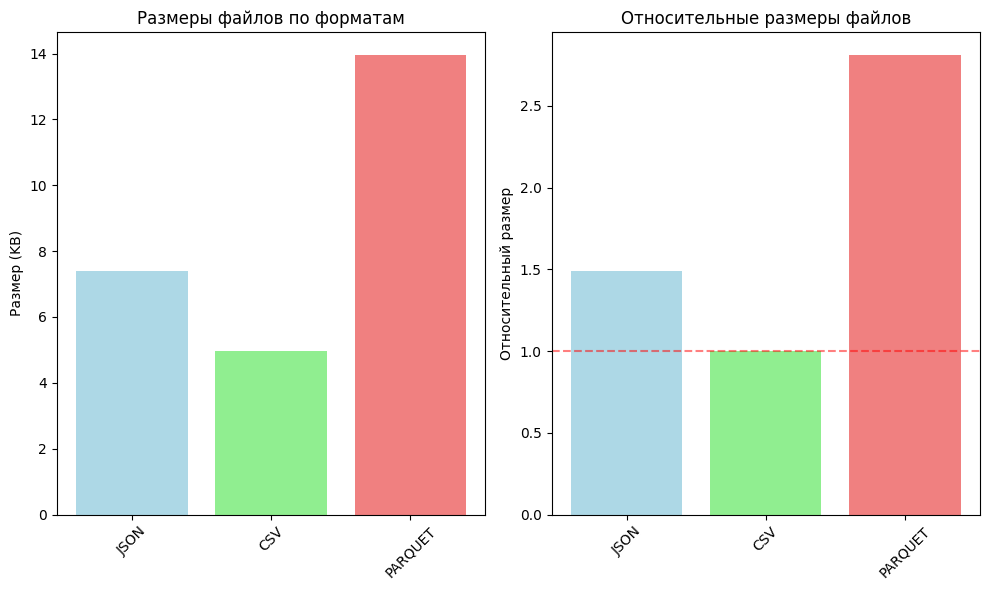

In [41]:
# Анализируем размеры файлов для обучающей выборки
print("\\n" + "="*50)
print("Сравнение размеров файлов (обучающая выборка):")

if train_files:
    size_comparison = compare_file_sizes(train_files)
    if not size_comparison.empty:
        print(size_comparison[["Format", "Size_KB", "Relative_Size"]].to_string(index=False))

        # Визуализация размеров файлов
        plt.figure(figsize=(10, 6))

        plt.subplot(1, 2, 1)
        plt.bar(size_comparison["Format"], size_comparison["Size_KB"],
                color=["lightblue", "lightgreen", "lightcoral", "lightyellow"])
        plt.ylabel("Размер (KB)")
        plt.title("Размеры файлов по форматам")
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        plt.bar(size_comparison["Format"], size_comparison["Relative_Size"],
                color=["lightblue", "lightgreen", "lightcoral", "lightyellow"])
        plt.ylabel("Относительный размер")
        plt.title("Относительные размеры файлов")
        plt.xticks(rotation=45)
        plt.axhline(y=1, color="red", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

In [42]:
# Демонстрация загрузки данных из разных форматов
print("="*50)
print("Демонстрация загрузки данных из разных форматов:")

if "csv" in train_files:
    # Загружаем CSV
    loaded_csv = pd.read_csv(train_files["csv"])
    print(f"CSV загружен: {len(loaded_csv)} записей, {len(loaded_csv.columns)} колонок")
    print(f"Колонки: {list(loaded_csv.columns)}")

if "json" in train_files:
    # Загружаем JSON
    loaded_json = pd.read_json(train_files["json"])
    print(f"JSON загружен: {len(loaded_json)} записей, {len(loaded_json.columns)} колонок")

if "parquet" in train_files:
    # Загружаем Parquet
    loaded_parquet = pd.read_parquet(train_files["parquet"])
    print(f"Parquet загружен: {len(loaded_parquet)} записей, {len(loaded_parquet.columns)} колонок")

print(f"Все данные успешно сохранены в {len(train_files)} форматах.")

Демонстрация загрузки данных из разных форматов:
CSV загружен: 5 записей, 11 колонок
Колонки: ['id', 'original_text', 'title', 'rating', 'processed_text', 'word_count', 'char_count', 'unique_word_count', 'avg_word_length', 'tokens_str', 'lemmas_str']
JSON загружен: 5 записей, 11 колонок
Parquet загружен: 5 записей, 11 колонок
Все данные успешно сохранены в 3 форматах.


## 6. Примеры использования OpenAI API и Hugging Face

### OpenAI API для анализа данных

Рассмотрим, как можно использовать LLM для анализа подготовленных данных:

In [43]:
# Инициализация клиента OpenAI
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))  # Замените на ваш API ключ

def create_sentiment_prompt(text: str) -> str:
    """Создание промпта для анализа тональности."""
    return f"""Определи тональность следующего отзыва на русском языке.

Отзыв: {text}

Возможные варианты ответа:
- positive (положительный)
- negative (отрицательный)
- neutral (нейтральный)

Учитывай контекст, сарказм и общее впечатление.

Ответ (одним словом):"""

def analyze_sentiment_openai(text: str, model: str = "gpt-3.5-turbo") -> dict[str, typing.Any]:
    """Анализ тональности с помощью OpenAI API."""
    try:
        prompt = create_sentiment_prompt(text)

        response = client.chat.completions.create(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "Ты эксперт по анализу тональности текста. Отвечай кратко и точно."
                },
                {"role": "user", "content": prompt}
            ],
            max_tokens=10,
            temperature=0
        )

        sentiment = response.choices[0].message.content.strip().lower()

        # Валидация ответа
        if sentiment not in ["positive", "negative", "neutral"]:
            sentiment = "neutral"  # По умолчанию, если ответ некорректный

        return {
            "sentiment": sentiment,
            "model": model,
            "tokens_used": response.usage.total_tokens,
            "success": True
        }

    except Exception as e:
        print(f"Ошибка при анализе: {e}")
        return {
            "sentiment": "neutral",
            "model": model,
            "tokens_used": 0,
            "success": False,
            "error": str(e)
        }

def batch_analyze_sentiment(texts: list[str], model: str = "gpt-3.5-turbo", delay: float = 1.0) -> list[dict]:
    """Пакетный анализ тональности с задержкой между запросами."""
    results = []
    total_tokens = 0

    for one_index, one_text in enumerate(texts):
        print(f"Анализ отзыва {one_index+1}/{len(texts)}...", end="\r")

        result = analyze_sentiment_openai(one_text, model)
        result["id"] = i
        result["original_text"] = one_text
        results.append(result)

        if result["success"]:
            total_tokens += result["tokens_used"]

        # Задержка между запросами для соблюдения rate limits
        if i < len(texts) - 1:
            time.sleep(delay)

    print(f"\nАнализ завершен. Использовано токенов: {total_tokens}")
    return results

In [44]:
# Демонстрация работы с примерными данными
# В реальном проекте замените на ваш processed_df
sample_reviews = [
    "Отличный товар, очень доволен покупкой! Рекомендую всем.",
    "Ужасное качество, деньги на ветер. Не советую никому.",
    "Обычный товар, ничего особенного. Цена соответствует качеству.",
    "Потрясающий сервис, быстрая доставка, товар как описано!",
    "Не работает как заявлено, очень разочарован покупкой."
]

print("Демонстрация анализа тональности с OpenAI API:")
print("="*60)

# Пример одного анализа
sample_text = sample_reviews[0]
print(f"Исходный текст: {sample_text}")

print("\nПромпт для анализа тональности:")
print("-" * 40)
sentiment_prompt = create_sentiment_prompt(sample_text)
print(sentiment_prompt)

# Анализ одного отзыва (раскомментируйте для тестирования)
single_result = analyze_sentiment_openai(sample_text)
print("Результат анализа:")
print(f"Тональность: {single_result['sentiment']}")
print(f"Модель: {single_result['model']}")
print(f"Токенов использовано: {single_result['tokens_used']}")

Демонстрация анализа тональности с OpenAI API:
Исходный текст: Отличный товар, очень доволен покупкой! Рекомендую всем.

Промпт для анализа тональности:
----------------------------------------
Определи тональность следующего отзыва на русском языке.

Отзыв: Отличный товар, очень доволен покупкой! Рекомендую всем.

Возможные варианты ответа:
- positive (положительный)
- negative (отрицательный)
- neutral (нейтральный)

Учитывай контекст, сарказм и общее впечатление.

Ответ (одним словом):
Результат анализа:
Тональность: positive
Модель: gpt-3.5-turbo
Токенов использовано: 170


### Hugging Face для предобученных моделей

Hugging Face предоставляет множество предобученных моделей для различных задач:

In [45]:
def load_sentiment_model() -> typing.Optional[pipeline]:
    """Загрузка предобученной модели для анализа тональности русского текста."""
    try:

        print("Загрузка модели анализа тональности...")

        # Русскоязычная модель для анализа тональности
        sentiment_model = pipeline(
            "sentiment-analysis",
            model="blanchefort/rubert-base-cased-sentiment-rusentiment",
            return_all_scores=True
        )

        print("✓ Модель тональности загружена успешно")
        return sentiment_model

    except ImportError:
        print("⚠ Transformers не установлен. Установите: pip install transformers torch")
        return None
    except Exception as e:
        print(f"⚠ Ошибка загрузки модели: {e}")
        print("Попробуйте другую модель или проверьте подключение к интернету")
        return None

def analyze_sentiment_hf(text: str, model: pipeline) -> dict[str, typing.Any]:
    """Анализ тональности одного текста с помощью Hugging Face."""
    if not model:
        return {
            "sentiment": "unknown",
            "confidence": 0.0,
            "all_scores": [],
            "processing_time": 0.0,
            "success": False,
            "error": "Model not loaded"
        }

    try:
        start_time = time.time()

        # Анализ тональности
        result = model(text)
        processing_time = time.time() - start_time

        scores = result[0] if isinstance(result[0], list) else result

        if scores and len(scores) > 0:
            best_sentiment = max(scores, key=lambda x: x["score"])

            # Маппинг лейблов модели к стандартным значениям
            label_mapping = {
                "POSITIVE": "positive",
                "NEGATIVE": "negative",
                "NEUTRAL": "neutral"
            }

            sentiment = label_mapping.get(best_sentiment["label"].upper(), best_sentiment["label"].lower())

            return {
                "sentiment": sentiment,
                "confidence": best_sentiment["score"],
                "all_scores": scores,
                "processing_time": processing_time,
                "success": True
            }
        return {
            "sentiment": "neutral",
            "confidence": 0.0,
            "all_scores": [],
            "processing_time": processing_time,
            "success": False,
            "error": "Empty result from model"
        }

    except Exception as e:
        return {
            "sentiment": "neutral",
            "confidence": 0.0,
            "all_scores": [],
            "processing_time": 0.0,
            "success": False,
            "error": str(e)
        }

def batch_analyze_sentiment_hf(texts: list[str], model: pipeline) -> list[dict[str, typing.Any]]:
    """Пакетный анализ тональности с Hugging Face."""
    results = []

    print(f"Начинаем анализ {len(texts)} текстов...")

    for one_index, one_text in enumerate(texts):
        if one_index % 10 == 0 or one_index == len(texts) - 1:
            print(f"Обработано: {one_index+1}/{len(texts)}", end="\r")

        result = analyze_sentiment_hf(one_text, model)
        result["id"] = one_index
        result["original_text"] = one_text
        results.append(result)

    print("✓ Пакетный анализ завершен")
    return results

def analyze_hf_results(results: list[dict[dict[str, typing.Any]]]) -> dict[str, typing.Any]:
    """Анализ результатов Hugging Face."""
    df = pd.DataFrame(results)

    # Статистика успешности
    success_rate = df["success"].mean() * 100
    successful_results = df[df["success"]]

    # Общие метрики
    total_time = df["processing_time"].sum()
    avg_time = df["processing_time"].mean()
    avg_confidence = successful_results["confidence"].mean() if len(successful_results) > 0 else 0

    # Распределение тональности
    sentiment_dist = successful_results["sentiment"].value_counts() if len(successful_results) > 0 else pd.Series()

    return {
        "total_texts": len(results),
        "success_rate": success_rate,
        "successful_count": len(successful_results),
        "total_time": total_time,
        "avg_time_per_text": avg_time,
        "avg_confidence": avg_confidence,
        "sentiment_distribution": sentiment_dist.to_dict(),
        "results_df": df
    }

In [46]:
# Демонстрация работы
print("Демонстрация анализа тональности с Hugging Face")
print("=" * 60)

# Примерные данные для демонстрации
sample_reviews = [
    "Отличный товар, очень доволен покупкой! Рекомендую всем.",
    "Ужасное качество, деньги на ветер. Не советую никому.",
    "Обычный товар, ничего особенного. Цена соответствует качеству.",
    "Потрясающий сервис, быстрая доставка, товар как описано!",
    "Не работает как заявлено, очень разочарован покупкой.",
    "Средненько, можно было и лучше за такие деньги.",
    "Супер! Именно то, что искал. Буду заказывать еще.",
    "Полное разочарование, вернул товар обратно в магазин."
]

print(f"Тестовые данные: {len(sample_reviews)} отзывов")

# Загрузка модели
sentiment_model = load_sentiment_model()

if sentiment_model:
    print("\n" + "=" * 60)
    print("АНАЛИЗ С HUGGING FACE МОДЕЛЬЮ")

    # Тест одного отзыва
    print("\nТест одного отзыва:")
    test_text = sample_reviews[0]
    print(f"Текст: {test_text}")

    single_result = analyze_sentiment_hf(test_text, sentiment_model)
    print("Результат:")
    print(f"  Тональность: {single_result['sentiment']}")
    print(f"  Уверенность: {single_result['confidence']:.3f}")
    print(f"  Время обработки: {single_result['processing_time']:.3f}с")
    print(f"  Успешно: {single_result['success']}")

    if single_result["all_scores"]:
        print("  Все оценки:")
        for one_score in single_result["all_scores"]:
            print(f"    {one_score['label']}: {one_score['score']:.3f}")

    # Пакетный анализ
    print("\nПакетный анализ всех отзывов:")
    batch_results = batch_analyze_sentiment_hf(sample_reviews, sentiment_model)

    # Анализ результатов
    analysis = analyze_hf_results(batch_results)

    print("\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА:")
    print(f"Всего текстов: {analysis['total_texts']}")
    print(f"Успешно обработано: {analysis['successful_count']} ({analysis['success_rate']:.1f}%)")
    print(f"Общее время: {analysis['total_time']:.3f}с")
    print(f"Среднее время на текст: {analysis['avg_time_per_text']:.3f}с")
    print(f"Средняя уверенность: {analysis['avg_confidence']:.3f}")

    print("\nРаспределение тональности:")
    for one_sentiment, one_count in analysis["sentiment_distribution"].items():
        print(f"  {one_sentiment}: {one_count}")

    # Детальные результаты
    print("\nДетальные результаты:")
    for one_index, one_result in enumerate(batch_results):
        status = "✓" if one_result["success"] else "✗"
        print(f"{status} Отзыв {one_index+1}: {one_result['original_text'][:40]}...")
        print(f"   Тональность: {one_result['sentiment']} (уверенность: {one_result['confidence']:.3f})")
        if not one_result["success"]:
            print(f"   Ошибка: {one_result.get('error', 'Unknown error')}")
        print()
else:
    print("\n⚠ Модель не загружена. Убедитесь что установлены библиотеки:")
    print("pip install transformers torch")
    print("\nАльтернативные модели для тестирования:")
    print("- cardiffnlp/twitter-roberta-base-sentiment-latest")
    print("- blanchefort/rubert-base-cased-sentiment-rusentiment")
    print("- sismetanin/rubert-ru-sentiment-rusentiment")
    analysis = None

Демонстрация анализа тональности с Hugging Face
Тестовые данные: 8 отзывов
Загрузка модели анализа тональности...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment-rusentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/495 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Модель тональности загружена успешно

АНАЛИЗ С HUGGING FACE МОДЕЛЬЮ

Тест одного отзыва:
Текст: Отличный товар, очень доволен покупкой! Рекомендую всем.
Результат:
  Тональность: positive
  Уверенность: 0.974
  Время обработки: 0.607с
  Успешно: True
  Все оценки:
    POSITIVE: 0.974

Пакетный анализ всех отзывов:
Начинаем анализ 8 текстов...
✓ Пакетный анализ завершен

📊 РЕЗУЛЬТАТЫ АНАЛИЗА:
Всего текстов: 8
Успешно обработано: 8 (100.0%)
Общее время: 2.518с
Среднее время на текст: 0.315с
Средняя уверенность: 0.826

Распределение тональности:
  negative: 4
  positive: 3
  neutral: 1

Детальные результаты:
✓ Отзыв 1: Отличный товар, очень доволен покупкой! ...
   Тональность: positive (уверенность: 0.974)

✓ Отзыв 2: Ужасное качество, деньги на ветер. Не со...
   Тональность: negative (уверенность: 0.966)

✓ Отзыв 3: Обычный товар, ничего особенного. Цена с...
   Тональность: neutral (уверенность: 0.455)

✓ Отзыв 4: Потрясающий сервис, быстрая доставка, то...
   Тональность: positive 

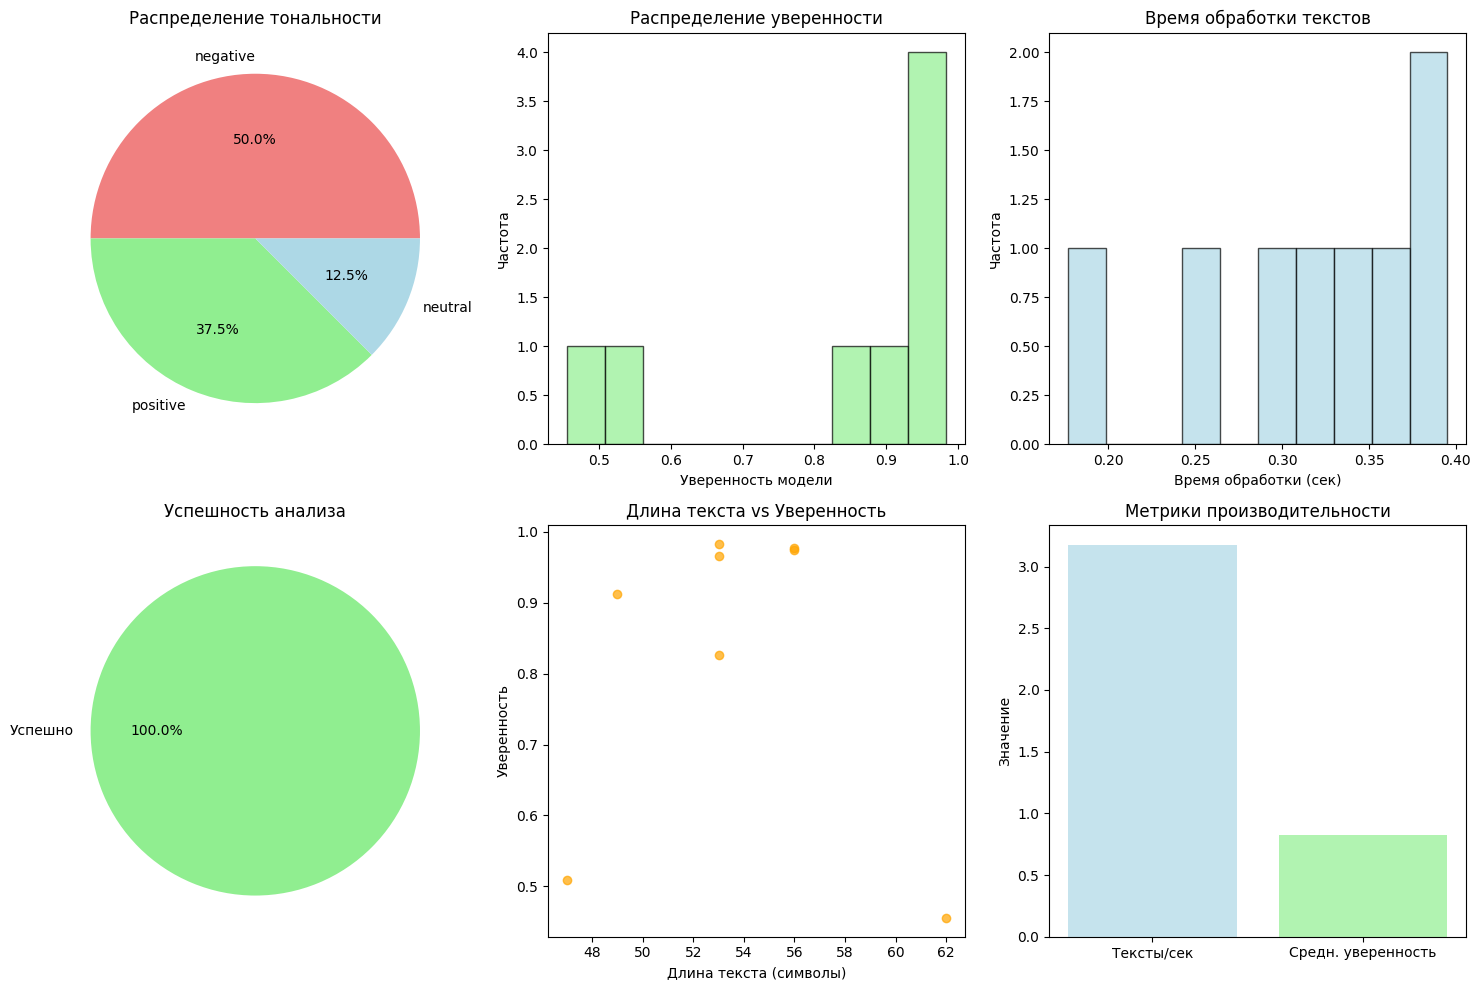


🎯 ЗАКЛЮЧЕНИЕ:
Модель Hugging Face показала 100.0% успешности
Среднее время обработки: 0.315с на текст
Средняя уверенность в предсказаниях: 0.826

Детальная статистика:
✓ Успешно обработано: 8 из 8

Распределение тональности:
  negative: 4 (50.0%)
  positive: 3 (37.5%)
  neutral: 1 (12.5%)


In [47]:
# Визуализация
if analysis is not None and analysis["successful_count"] > 0:
    plt.figure(figsize=(15, 10))

    # График 1: Распределение тональности
    plt.subplot(2, 3, 1)
    sentiments = list(analysis["sentiment_distribution"].keys())
    counts = list(analysis["sentiment_distribution"].values())
    colors = ["lightgreen" if s == "positive" else "lightcoral" if s == "negative" else "lightblue"
                for s in sentiments]
    plt.pie(counts, labels=sentiments, colors=colors, autopct="%1.1f%%")
    plt.title("Распределение тональности")

    # График 2: Распределение уверенности
    plt.subplot(2, 3, 2)
    successful_df = analysis["results_df"][analysis["results_df"]["success"]]
    plt.hist(successful_df["confidence"], bins=10, alpha=0.7, color="lightgreen", edgecolor="black")
    plt.xlabel("Уверенность модели")
    plt.ylabel("Частота")
    plt.title("Распределение уверенности")

    # График 3: Время обработки
    plt.subplot(2, 3, 3)
    plt.hist(analysis["results_df"]["processing_time"], bins=10, alpha=0.7, color="lightblue", edgecolor="black")
    plt.xlabel("Время обработки (сек)")
    plt.ylabel("Частота")
    plt.title("Время обработки текстов")

    # График 4: Успешность по тексту (ИСПРАВЛЕНО)
    plt.subplot(2, 3, 4)
    success_counts = analysis["results_df"]["success"].value_counts()

    # Создаем правильные labels на основе фактических значений
    labels = []
    colors_success = []
    for value in success_counts.index:
        if value:
            labels.append("Успешно")
            colors_success.append("lightgreen")
        else:
            labels.append("Ошибка")
            colors_success.append("lightcoral")

    plt.pie(success_counts.values, labels=labels, colors=colors_success, autopct="%1.1f%%")
    plt.title("Успешность анализа")

    # График 5: Длина текста vs уверенность
    plt.subplot(2, 3, 5)
    # Безопасное получение данных для успешных результатов
    successful_results = [result for result in batch_results if result["success"]]
    if successful_results:
        text_lengths = [len(result["original_text"]) for result in successful_results]
        confidences = [result["confidence"] for result in successful_results]
        plt.scatter(text_lengths, confidences, alpha=0.7, color="orange")
        plt.xlabel("Длина текста (символы)")
        plt.ylabel("Уверенность")
        plt.title("Длина текста vs Уверенность")
    else:
        plt.text(0.5, 0.5, "Нет успешных\nрезультатов", ha="center", va="center", transform=plt.gca().transAxes)
        plt.title("Длина текста vs Уверенность")

    # График 6: Производительность
    plt.subplot(2, 3, 6)
    if analysis["avg_time_per_text"] > 0:
        texts_per_second = 1 / analysis["avg_time_per_text"]
        metrics = ["Тексты/сек", "Средн. уверенность"]
        values = [texts_per_second, analysis["avg_confidence"]]
        colors_perf = ["lightblue", "lightgreen"]

        # Нормализуем значения для лучшего отображения
        if texts_per_second > 10:
            # Если слишком большое значение, покажем отдельно
            plt.bar(["Средн. уверенность"], [analysis["avg_confidence"]],
                    color=["lightgreen"], alpha=0.7)
            plt.text(0, analysis["avg_confidence"] + 0.05, f"{texts_per_second:.1f} тек/сек",
                    ha="center", fontsize=10)
            plt.title("Метрики производительности")
            plt.ylabel("Уверенность")
        else:
            plt.bar(metrics, values, color=colors_perf, alpha=0.7)
            plt.title("Метрики производительности")
            plt.ylabel("Значение")
    else:
        plt.text(0.5, 0.5, "Нет данных\nо времени", ha="center", va="center", transform=plt.gca().transAxes)
        plt.title("Метрики производительности")

    plt.tight_layout()
    plt.show()

# Более безопасный вывод заключения
if analysis is not None:
    print("\n🎯 ЗАКЛЮЧЕНИЕ:")
    print(f"Модель Hugging Face показала {analysis['success_rate']:.1f}% успешности")
    print(f"Среднее время обработки: {analysis['avg_time_per_text']:.3f}с на текст")
    print(f"Средняя уверенность в предсказаниях: {analysis['avg_confidence']:.3f}")

    # Дополнительная статистика
    total_successful = analysis["successful_count"]
    total_texts = analysis["total_texts"]
    failed_count = total_texts - total_successful

    print("\nДетальная статистика:")
    print(f"✓ Успешно обработано: {total_successful} из {total_texts}")
    if failed_count > 0:
        print(f"✗ Ошибок обработки: {failed_count}")

    if analysis["sentiment_distribution"]:
        print("\nРаспределение тональности:")
        for sentiment, count in analysis["sentiment_distribution"].items():
            percentage = (count / total_successful) * 100 if total_successful > 0 else 0
            print(f"  {sentiment}: {count} ({percentage:.1f}%)")

    # Сохранение результатов (опционально)
    # analysis['results_df'].to_csv('hf_sentiment_results.csv', index=False)
    # print("\nРезультаты сохранены в 'hf_sentiment_results.csv'")
else:
    print("⚠ Анализ не выполнен или нет данных для отображения")

## Практическое упражнение

Теперь объединим все изученные концепции в комплексном упражнении:

In [48]:
def create_sentiment_dataset(df: pd.DataFrame, sentiment_results: list[dict]) -> list[dict]:
    """Создание датасета только для анализа тональности."""
    instruction_dataset = []

    for one_row_index, one_row_content in df.iterrows():
        text = one_row_content["processed_text"]

        # Получаем результат анализа тональности
        if one_row_index < len(sentiment_results):
            sentiment = sentiment_results[one_row_index].get("sentiment", "neutral")
        else:
            # Простая эвристика на основе рейтинга, если нет результатов анализа
            rating = one_row_content.get("rating", 3)
            if rating >= 4:
                sentiment = "positive"
            elif rating <= 2:
                sentiment = "negative"
            else:
                sentiment = "neutral"

        # Создаем instruction пример
        instruction_item = {
            "instruction": "Определи тональность русскоязычного отзыва. Ответь одним словом: positive, negative или neutral.",
            "input": text,
            "output": sentiment,
            "metadata": {
                "original_rating": one_row_content.get("rating", None),
                "text_length": len(text),
                "word_count": len(text.split())
            }
        }
        instruction_dataset.append(instruction_item)

    return instruction_dataset

def create_openai_format(instruction_data: list[dict]) -> list[dict]:
    """Преобразование в формат для OpenAI fine-tuning."""
    openai_dataset = []

    for one_item in instruction_data:
        openai_item = {
            "messages": [
                {
                    "role": "system",
                    "content": "Ты эксперт по анализу тональности русскоязычных отзывов. Отвечай точно и кратко."
                },
                {
                    "role": "user",
                    "content": f"{one_item['instruction']}\n\nОтзыв: {one_item['input']}"
                },
                {
                    "role": "assistant",
                    "content": one_item["output"]
                }
            ]
        }
        openai_dataset.append(openai_item)

    return openai_dataset

def analyze_dataset(dataset: list[dict]) -> dict[str, typing.Any]:
    """Анализ созданного датасета."""
    # Общая статистика
    total_examples = len(dataset)

    # Анализ тональности
    sentiments = [one_item["output"] for one_item in dataset]
    sentiment_counts = pd.Series(sentiments).value_counts()

    # Анализ длин текстов
    input_lengths = [len(one_item["input"]) for one_item in dataset]
    output_lengths = [len(one_item["output"]) for one_item in dataset]

    return {
        "total_examples": total_examples,
        "sentiment_distribution": sentiment_counts.to_dict(),
        "avg_input_length": np.mean(input_lengths),
        "avg_output_length": np.mean(output_lengths),
        "min_input_length": np.min(input_lengths),
        "max_input_length": np.max(input_lengths),
        "input_lengths": input_lengths
    }

def save_datasets(
        instruction_data: list[dict],
        openai_data: list[dict],
        train_split: float = 0.8
) -> dict[str, typing.Any]:
    """Сохранение датасетов в различных форматах."""
    print("Сохранение датасетов...")

    # Разделение на train/validation
    np.random.seed(42)
    shuffled_indices = np.random.permutation(len(instruction_data))
    train_size = int(len(instruction_data) * train_split)

    train_indices = shuffled_indices[:train_size]
    val_indices = shuffled_indices[train_size:]

    # Создаем разделенные данные
    train_data = [instruction_data[i] for i in train_indices]
    val_data = [instruction_data[i] for i in val_indices]

    train_openai = [openai_data[i] for i in train_indices]
    val_openai = [openai_data[i] for i in val_indices]

    # Сохраняем полный датасет
    with open("sentiment_dataset.json", "w", encoding="utf-8") as f:
        json.dump(instruction_data, f, ensure_ascii=False, indent=2)

    # Сохраняем в формате OpenAI JSONL
    with open("sentiment_openai_full.jsonl", "w", encoding="utf-8") as f:
        f.writelines(json.dumps(item, ensure_ascii=False) + "\n" for item in openai_data)

    # Сохраняем train/val для OpenAI
    with open("sentiment_train.jsonl", "w", encoding="utf-8") as f:
        f.writelines(json.dumps(item, ensure_ascii=False) + "\n" for item in train_openai)

    with open("sentiment_val.jsonl", "w", encoding="utf-8") as f:
        f.writelines(json.dumps(item, ensure_ascii=False) + "\n" for item in val_openai)

    return {
        "train_size": len(train_data),
        "val_size": len(val_data),
        "files_created": [
            "sentiment_dataset.json",
            "sentiment_openai_full.jsonl",
            "sentiment_train.jsonl",
            "sentiment_val.jsonl"
        ]
    }

In [49]:
# Демонстрация создания датасета
print("Создание датасета для fine-tuning анализа тональности")
print("=" * 60)

# Примерные данные (замените на ваши processed_df и результаты анализа)
sample_data = {
    "processed_text": [
        "Отличный товар, очень доволен покупкой! Рекомендую всем.",
        "Ужасное качество, деньги на ветер. Не советую никому.",
        "Обычный товар, ничего особенного. Цена соответствует качеству.",
        "Потрясающий сервис, быстрая доставка, товар как описано!",
        "Не работает как заявлено, очень разочарован покупкой.",
        "Средненько, можно было и лучше за такие деньги.",
        "Супер! Именно то, что искал. Буду заказывать еще.",
        "Полное разочарование, вернул товар обратно в магазин."
    ],
    "rating": [5, 1, 3, 5, 2, 3, 5, 1]
}

sample_df = pd.DataFrame(sample_data)

# Примерные результаты анализа тональности
sample_sentiment_results = [
    {"sentiment": "positive"},
    {"sentiment": "negative"},
    {"sentiment": "neutral"},
    {"sentiment": "positive"},
    {"sentiment": "negative"},
    {"sentiment": "neutral"},
    {"sentiment": "positive"},
    {"sentiment": "negative"}
]

print(f"Исходных данных: {len(sample_df)} отзывов")

# Создаем instruction датасет
instruction_data = create_sentiment_dataset(sample_df, sample_sentiment_results)
print(f"Создано instruction примеров: {len(instruction_data)}")

# Анализируем датасет
analysis = analyze_dataset(instruction_data)

print("\n📊 Анализ датасета:")
print(f"Общее количество примеров: {analysis['total_examples']}")
print(f"Средняя длина входного текста: {analysis['avg_input_length']:.1f} символов")
print(f"Диапазон длин: {analysis['min_input_length']}-{analysis['max_input_length']} символов")

print("\nРаспределение тональности:")
for one_sentiment, one_count in analysis["sentiment_distribution"].items():
    percentage = (one_count / analysis["total_examples"]) * 100
    print(f"  {one_sentiment}: {one_count} ({percentage:.1f}%)")

# Показываем примеры
print("\n" + "=" * 60)
print("Примеры instruction данных:")

for one_index, one_example in enumerate(instruction_data[:3]):
    print(f"\nПример {one_index+1}:")
    print(f"Instruction: {one_example['instruction']}")
    print(f"Input: {one_example['input'][:60]}...")
    print(f"Output: {one_example['output']}")
    print(f"Metadata: {one_example['metadata']}")

# Создаем датасет в формате OpenAI
openai_data = create_openai_format(instruction_data)

# Сохраняем датасеты
save_info = save_datasets(instruction_data, openai_data)

print("\n" + "=" * 60)
print("Результаты сохранения:")
print(f"Train примеров: {save_info['train_size']}")
print(f"Validation примеров: {save_info['val_size']}")

print("\nСозданные файлы:")
for one_filename in save_info["files_created"]:
    if os.path.exists(one_filename):
        size_kb = os.path.getsize(one_filename) / 1024
        print(f"  ✓ {one_filename:<30} {size_kb:>6.1f} KB")

Создание датасета для fine-tuning анализа тональности
Исходных данных: 8 отзывов
Создано instruction примеров: 8

📊 Анализ датасета:
Общее количество примеров: 8
Средняя длина входного текста: 53.6 символов
Диапазон длин: 47-62 символов

Распределение тональности:
  positive: 3 (37.5%)
  negative: 3 (37.5%)
  neutral: 2 (25.0%)

Примеры instruction данных:

Пример 1:
Instruction: Определи тональность русскоязычного отзыва. Ответь одним словом: positive, negative или neutral.
Input: Отличный товар, очень доволен покупкой! Рекомендую всем....
Output: positive
Metadata: {'original_rating': 5, 'text_length': 56, 'word_count': 7}

Пример 2:
Instruction: Определи тональность русскоязычного отзыва. Ответь одним словом: positive, negative или neutral.
Input: Ужасное качество, деньги на ветер. Не советую никому....
Output: negative
Metadata: {'original_rating': 1, 'text_length': 53, 'word_count': 8}

Пример 3:
Instruction: Определи тональность русскоязычного отзыва. Ответь одним словом: positiv

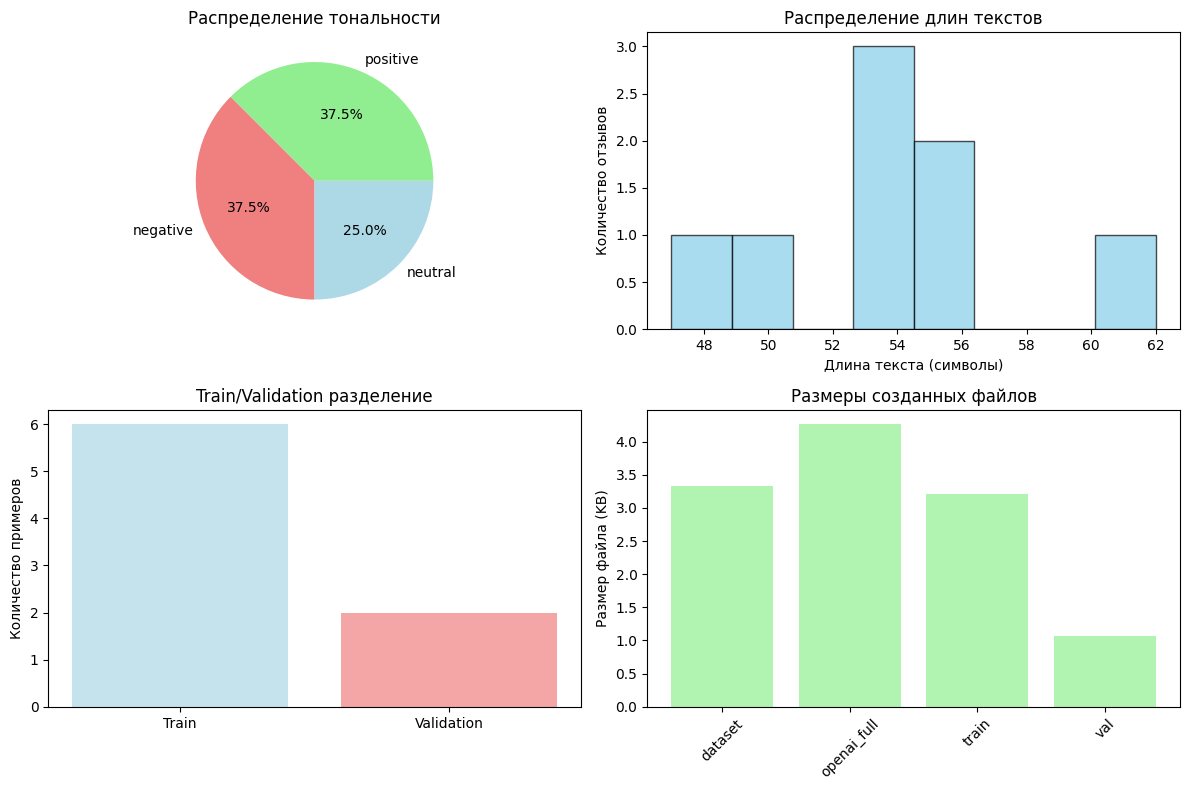

Создание датасета завершено!
Готов для fine-tuning модели анализа тональности
Пример OpenAI формата:
{
  "messages": [
    {
      "role": "system",
      "content": "Ты эксперт по анализу тональности русскоязычных отзывов. Отвечай точно и кратко."
    },
    {
      "role": "user",
      "content": "Определи тональность русскоязычного отзыва. Ответь одним словом: positive, negative или neutral.\n\nОтзыв: Отличный товар, очень доволен покупкой! Рекомендую всем."
    },
    {
      "role": "assistant",
      "content": "positive"
    }
  ]
}


In [50]:
# Визуализация датасета
plt.figure(figsize=(12, 8))

# График 1: Распределение тональности
plt.subplot(2, 2, 1)
sentiments = list(analysis["sentiment_distribution"].keys())
counts = list(analysis["sentiment_distribution"].values())
colors = ["lightgreen" if one_s == "positive" else "lightcoral" if one_s == "negative" else "lightblue"
          for one_s in sentiments]
plt.pie(counts, labels=sentiments, colors=colors, autopct="%1.1f%%")
plt.title("Распределение тональности")

# График 2: Распределение длин текстов
plt.subplot(2, 2, 2)
plt.hist(analysis["input_lengths"], bins=8, alpha=0.7, color="skyblue", edgecolor="black")
plt.xlabel("Длина текста (символы)")
plt.ylabel("Количество отзывов")
plt.title("Распределение длин текстов")

# График 3: Train/Val разделение
plt.subplot(2, 2, 3)
split_data = ["Train", "Validation"]
split_counts = [save_info["train_size"], save_info["val_size"]]
plt.bar(split_data, split_counts, color=["lightblue", "lightcoral"], alpha=0.7)
plt.ylabel("Количество примеров")
plt.title("Train/Validation разделение")

# График 4: Размеры файлов
plt.subplot(2, 2, 4)
file_sizes = []
file_names = []
for one_filename in save_info["files_created"]:
    if os.path.exists(one_filename):
        size_kb = os.path.getsize(one_filename) / 1024
        file_sizes.append(size_kb)
        # Укорачиваем имена файлов для отображения
        short_name = one_filename.replace("sentiment_", "").replace(".jsonl", "").replace(".json", "")
        file_names.append(short_name)

plt.bar(file_names, file_sizes, color="lightgreen", alpha=0.7)
plt.ylabel("Размер файла (KB)")
plt.title("Размеры созданных файлов")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Создание датасета завершено!")
print("Готов для fine-tuning модели анализа тональности")

# Показываем пример OpenAI формата
print("Пример OpenAI формата:")
print(json.dumps(openai_data[0], ensure_ascii=False, indent=2))

## Заключение

### Что мы изучили:
1. **Основы работы с данными** в Python с помощью Pandas и NumPy
2. **Парсинг и очистку текстовых данных** с учетом специфики русского языка
3. **Токенизацию и нормализацию** текстов
4. **Особенности русскоязычной обработки**: морфология, падежи, опечатки
5. **Формирование выборок** для машинного обучения
6. **Сериализацию данных** в форматах JSON, CSV, Parquet
7. **Интеграцию с LLM API** (OpenAI) и предобученными моделями (Hugging Face)

### Ключевые навыки:
- Предобработка данных для LLM
- Работа с русскоязычными текстами
- Подготовка данных в различных форматах
- Интеграция с современными NLP инструментами

### Дополнительные ресурсы:
- Документация Pandas: https://pandas.pydata.org/
- Hugging Face Hub: https://huggingface.co/models
- OpenAI API: https://platform.openai.com/docs/